# 01. LunarLander-v2 PPO 학습
> **Google Colab T4** 에서 위에서 아래로 순서대로 셀을 실행하세요.

## 1. 패키지 설치

In [2]:
!apt-get install -y swig > /dev/null 2>&1  # box2d-py 빌드에 필요
!pip install -q stable-baselines3==2.3.2 gymnasium[box2d]==0.29.1 shimmy==1.3.0 tensorboard>=2.9.1

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.


## 2. 환경 확인

In [3]:
import gymnasium as gym
import numpy as np

env = gym.make('LunarLander-v2')
obs, _ = env.reset()
print('Observation shape:', obs.shape)
print('Action space:', env.action_space)
env.close()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: De

Observation shape: (8,)
Action space: Discrete(4)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. PPO 학습

In [4]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback
import os

os.makedirs('/content/results/models', exist_ok=True)
os.makedirs('/content/results/plots', exist_ok=True)

vec_env = make_vec_env('LunarLander-v2', n_envs=4)

model = PPO(
    'MlpPolicy', vec_env,
    learning_rate=3e-4, n_steps=1024, batch_size=64,
    n_epochs=10, gamma=0.999, gae_lambda=0.98, ent_coef=0.01,
    verbose=1, device='auto',
)

eval_callback = EvalCallback(
    make_vec_env('LunarLander-v2', n_envs=1),
    best_model_save_path='/content/results/models/',
    log_path='/content/results/',
    eval_freq=5000, n_eval_episodes=10, deterministic=True, verbose=1,
)

model.learn(total_timesteps=300_000, callback=eval_callback)
model.save('/content/results/models/ppo_lunarlander')
print('학습 완료')

Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 87.7     |
|    ep_rew_mean     | -177     |
| time/              |          |
|    fps             | 1366     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 4096     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 92            |
|    ep_rew_mean          | -170          |
| time/                   |               |
|    fps                  | 960           |
|    iterations           | 2             |
|    time_elapsed         | 8             |
|    total_timesteps      | 8192          |
| train/                  |               |
|    approx_kl            | 0.007681432   |
|    clip_fraction        | 0.0532        |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.38         |
|    explained_variance   | -0.0008277893 |
|    learning_rate        | 0.0003        |
|    loss                 | 1.85e+03      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00637      |
|    value_loss           | 5.11e+03      |
-------------------------------------------
------------------------------------------
| rollout/                |      

## 4. 학습 곡선 시각화

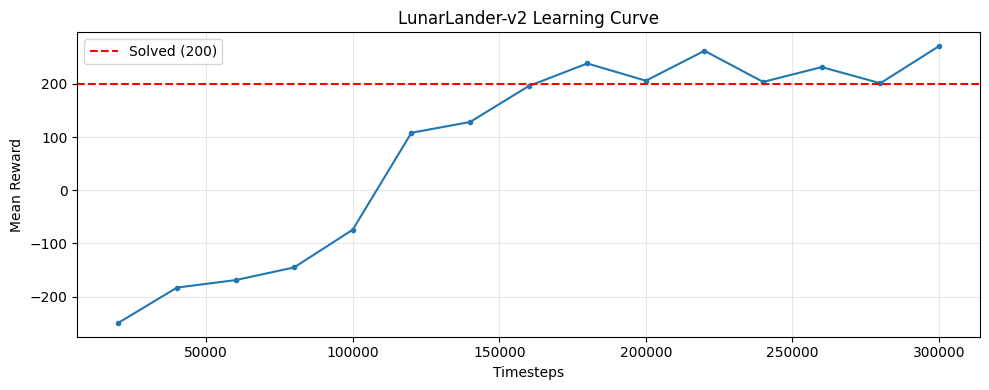

In [5]:
import matplotlib.pyplot as plt
import numpy as np

results = np.load('/content/results/evaluations.npz')
timesteps = results['timesteps']
mean_rewards = results['results'].mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(timesteps, mean_rewards, marker='o', markersize=3)
plt.axhline(200, color='red', linestyle='--', label='Solved (200)')
plt.xlabel('Timesteps'); plt.ylabel('Mean Reward'); plt.title('LunarLander-v2 Learning Curve')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('/content/results/plots/lunarlander_curve.png', dpi=150)
plt.show()

## 5. 에이전트 평가

In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
import gymnasium as gym

best_model = PPO.load('/content/results/models/best_model')
eval_env = gym.make('LunarLander-v2')
mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20, deterministic=True)
print(f'Mean reward: {mean_reward:.2f} ± {std_reward:.2f}')
eval_env.close()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean reward: 259.87 ± 31.98


---
다음 → **02_trading_ppo.ipynb** 에서 동일한 PPO 구조를 커스텀 트레이딩 환경에 전이합니다.